# Credit Risk Modeling Walkthrough

This notebook supports the `predict_credit_risk` project. It focuses on three goals:

1. understand the dataset used by the API and training pipeline,
2. apply the same cleaning logic used in the package code, and
3. inspect whether the model is learning a useful signal without badly overfitting.

Each code cell is introduced by a markdown cell that explains what it does and why it matters.


## Cell 1: Imports and notebook setup

This cell imports the libraries and project helpers used throughout the notebook.

- `Path` and `sys` help the notebook find the repository root even when it is opened from the `notebooks/` folder.
- `pandas` handles tabular exploration.
- `matplotlib` is used for a small feature-importance chart later.
- The functions imported from `predict_credit_risk.training` keep this notebook aligned with the actual training code used by the project.


In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from predict_credit_risk.training import (
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    build_pipeline,
    choose_decision_threshold,
    clean_credit_data,
    predict_from_probabilities,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


## Cell 2: Load the raw dataset and preview the schema

This cell reads the raw credit-risk dataset from the local `dataset/` folder and gives a first look at the project inputs.

It answers basic questions that matter before modeling:

- how many rows and columns are available,
- what the feature names look like,
- whether the target column is present, and
- what a typical record looks like.


In [2]:
dataset_path = repo_root / "dataset" / "credit_risk_dataset.csv"
df_raw = pd.read_csv(dataset_path)

print(f"Dataset path: {dataset_path}")
print(f"Raw shape: {df_raw.shape}")
display(df_raw.head())
display(df_raw[FEATURE_COLUMNS + [TARGET_COLUMN]].describe(include="all").transpose())


Dataset path: c:\Users\magun\Videos\machine\dataset\credit_risk_dataset.csv
Raw shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,"32,581.000",NaN,NaN,NaN,27.735,6.348,20.000,23.000,26.000,30.000,144.000
person_income,"32,581.000",NaN,NaN,NaN,"66,074.848","61,983.119","4,000.000","38,500.000","55,000.000","79,200.000","6,000,000.000"
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,"31,686.000",NaN,NaN,NaN,4.790,4.143,0.000,2.000,4.000,7.000,123.000
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,"32,581.000",NaN,NaN,NaN,"9,589.371","6,322.087",500.000,"5,000.000","8,000.000","12,200.000","35,000.000"
loan_int_rate,"29,465.000",NaN,NaN,NaN,11.012,3.240,5.420,7.900,10.990,13.470,23.220
loan_percent_income,"32,581.000",NaN,NaN,NaN,0.170,0.107,0.000,0.090,0.150,0.230,0.830
cb_person_default_on_file,32581,2,N,26836,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cell 3: Inspect missing values and class balance

This cell checks two things that strongly affect model behavior.

First, it measures missing values so we know which features need imputation.
Second, it shows the target distribution so we can see whether loan default is imbalanced.

That class balance matters because a model can look accurate while still doing a poor job catching risky applicants.


In [3]:
missing_summary = pd.DataFrame(
    {
        "missing_count": df_raw.isna().sum(),
        "missing_pct": (df_raw.isna().mean() * 100).round(2),
    }
).sort_values("missing_count", ascending=False)

class_balance = pd.DataFrame(
    {
        "count": df_raw[TARGET_COLUMN].value_counts().sort_index(),
        "pct": (df_raw[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(2),
    }
)

print("Missing values by column")
display(missing_summary)
print("Loan status distribution")
display(class_balance)


Missing values by column


,missing_count,missing_pct
loan_int_rate,3116,9.560
person_emp_length,895,2.750
person_income,0,0.000
person_age,0,0.000
person_home_ownership,0,0.000
loan_intent,0,0.000
loan_grade,0,0.000
loan_amnt,0,0.000
loan_status,0,0.000
loan_percent_income,0,0.000


Loan status distribution


,count,pct
loan_status,,
0,25473,78.180
1,7108,21.820


## Cell 4: Apply the same cleaning rules used by the project package

This cell deliberately reuses `clean_credit_data()` from the main training module instead of inventing notebook-only logic.

The function removes duplicate rows, coerces numeric fields, and drops records with impossible employment-length values.


In [4]:
df_clean, removed_rows = clean_credit_data(df_raw)

print(f"Rows before cleaning: {len(df_raw):,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows removed:         {removed_rows:,}")
display(df_clean.head())


Rows before cleaning: 32,581
Rows after cleaning:  32,414
Rows removed:         2


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4
5,21,9900,OWN,2.000,VENTURE,A,2500,7.140,1,0.250,N,2


## Cell 5: Create train, validation, and test splits

This cell prepares the data for model evaluation.

- the training split is used to fit the first model,
- the validation split is used to choose a decision threshold,
- the test split is reserved for the final performance check.

Keeping a separate test split gives us a cleaner read on overfitting because the model does not tune itself directly against the test set.


In [5]:
X = df_clean[FEATURE_COLUMNS]
y = df_clean[TARGET_COLUMN]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full,
)

print(f"Train shape:      {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape:       {X_test.shape}")


Train shape:      (19448, 11)
Validation shape: (6483, 11)
Test shape:       (6483, 11)


## Cell 6: Train the model and tune the decision threshold

This cell fits the same pipeline used in the project package. It then scores the validation split and selects a threshold with `choose_decision_threshold()`.

The threshold step matters here because this project cares about identifying risky loans, not only about default probability ranking.
A tuned threshold can improve recall for the risky class without rewriting the model itself.


In [6]:
tuning_model = build_pipeline(X_train)
tuning_model.fit(X_train, y_train)

val_probabilities = tuning_model.predict_proba(X_val)[:, 1]
threshold_summary = choose_decision_threshold(y_val, val_probabilities)
threshold = threshold_summary["threshold"]

print(f"Chosen threshold: {threshold:.4f}")
display(pd.DataFrame([threshold_summary]))


Chosen threshold: 0.3554


,threshold,fbeta_score,precision,recall,beta
0,0.355,0.779,0.622,0.831,2.000


## Cell 7: Compare train, validation, and test performance

This is the key overfitting check.

The idea is simple: if training metrics are much stronger than validation and test metrics, the model may be memorizing patterns that do not generalize well.
If the gap is moderate and the validation and test scores stay in the same neighborhood, the model is behaving more credibly.


In [7]:
def metric_row(split_name, y_true, probabilities, threshold_value):
    predictions = predict_from_probabilities(probabilities, threshold_value)
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, predictions),
        "risk_precision": precision_score(y_true, predictions),
        "risk_recall": recall_score(y_true, predictions),
        "positive_rate": predictions.mean(),
    }

train_probabilities = tuning_model.predict_proba(X_train)[:, 1]
train_metrics = metric_row("train", y_train, train_probabilities, threshold)
val_metrics = metric_row("validation", y_val, val_probabilities, threshold)

final_model = build_pipeline(X_train_full)
final_model.fit(X_train_full, y_train_full)
test_probabilities = final_model.predict_proba(X_test)[:, 1]
test_metrics = metric_row("test", y_test, test_probabilities, threshold)

metrics_df = pd.DataFrame([train_metrics, val_metrics, test_metrics]).set_index("split")
display(metrics_df.round(4))


,accuracy,risk_precision,risk_recall,positive_rate
split,,,,
train,0.882,0.679,0.873,0.281
validation,0.853,0.622,0.832,0.292
test,0.847,0.609,0.836,0.300


## Cell 8: Inspect the most influential engineered features

This final code cell looks inside the fitted random forest and plots the ten strongest feature importances.

The point is not to claim causal truth. Instead, it gives a quick, interpretable picture of what the model is paying attention to.


,importance
cat__person_home_ownership_OWN,0.023
cat__loan_grade_C,0.025
cat__person_home_ownership_MORTGAGE,0.025
cat__loan_grade_A,0.028
num__loan_amnt,0.052
cat__person_home_ownership_RENT,0.067
cat__loan_grade_D,0.089
num__loan_int_rate,0.133
num__person_income,0.162
num__loan_percent_income,0.239


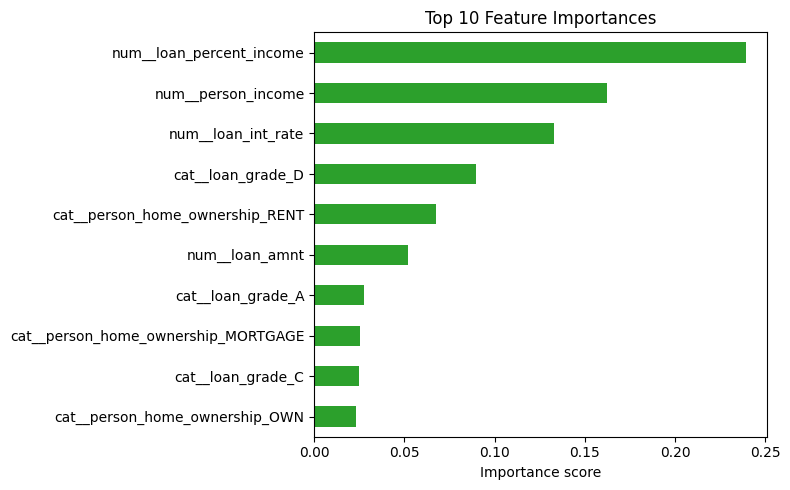

In [8]:
preprocess = final_model.named_steps["preprocess"]
classifier = final_model.named_steps["classifier"]
feature_names = preprocess.get_feature_names_out()

feature_importance = (
    pd.Series(classifier.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

display(feature_importance.to_frame("importance"))
feature_importance.plot(kind="barh", figsize=(8, 5), color="#2ca02c")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()


## Notebook takeaway

By the time you reach this point, the notebook has mirrored the real project workflow:

- load the same credit-risk dataset,
- clean it with the same reusable package function,
- train the same style of pipeline,
- tune the decision threshold, and
- check whether performance stays stable outside the training split.

That makes the notebook a supporting document for the repository rather than a disconnected experiment.
